# Unemployment Analysis in India

**Objective:** Analyse regional and temporal trends in India's unemployment rate, with a focus on the impact of the COVID-19 pandemic.

**Dataset:** Unemployment in India (Kaggle) — includes unemployment rate, employment count, and labour participation rate by region and date.

**Approach:** Data cleaning → EDA → Time-series and regional visualisation → Pre-COVID vs Post-COVID comparison → Business/policy observations.

## 1. Import Libraries

In [22]:
# Data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

## 2. Load the Dataset

In [21]:
# Load the dataset
df = pd.read_csv('/content/Unemployment_Rate_upto_11_2020.csv')

# Clean column names: remove leading/trailing spaces
df.columns = df.columns.str.strip()

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


## 3. Data Cleaning and Type Conversion

In [20]:
# Check data types before cleaning
print("Data types before cleaning:\n", df.dtypes)

# Convert Date column from string to datetime.
# dayfirst=True because the format is DD-MM-YYYY
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Rename Region.1 to something clearer — it actually represents the zone (South/North/etc.)
df.rename(columns={'Region.1': 'Zone'}, inplace=True)

# Check for missing values
print("\nMissing values:\n", df.isnull().sum())

# Check for duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

print("\nData types after cleaning:\n", df.dtypes)
df.head()

Data types before cleaning:
 Region                                             object
Date                                       datetime64[ns]
Frequency                                          object
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                  int64
Estimated Labour Participation Rate (%)           float64
Zone                                               object
longitude                                         float64
latitude                                          float64
dtype: object

Missing values:
 Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Zone                                       0
longitude                                  0
latitude                                   0
dtype: int64

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Zone,longitude,latitude
0,Andhra Pradesh,2020-01-31,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,2020-02-29,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,2020-03-31,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,2020-04-30,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,2020-05-31,M,17.43,12988845,36.46,South,15.9129,79.74


**Observations:**
- The dataset has 267 rows and 9 columns.
- The `Date` column was successfully converted to datetime format.
- `Region.1` was renamed to `Zone` since it represents geographical zones (South, North, East, West, etc.), not a second region column.
- There are no missing values and no duplicate rows, so no imputation or row removal is needed.

## 4. Basic Exploratory Data Analysis

In [19]:
print("Shape:", df.shape)
print("\nUnique regions:", df['Region'].nunique())
print(df['Region'].unique())

print("\nUnique zones:", df['Zone'].unique())

print("\nDate range:", df['Date'].min(), "to", df['Date'].max())

df.describe()

Shape: (267, 9)

Unique regions: 27
['Andhra Pradesh' 'Assam' 'Bihar' 'Chhattisgarh' 'Delhi' 'Goa' 'Gujarat'
 'Haryana' 'Himachal Pradesh' 'Jammu & Kashmir' 'Jharkhand' 'Karnataka'
 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Meghalaya' 'Odisha' 'Puducherry'
 'Punjab' 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana' 'Tripura'
 'Uttar Pradesh' 'Uttarakhand' 'West Bengal']

Unique zones: ['South' 'Northeast' 'East' 'West' 'North']

Date range: 2020-01-31 00:00:00 to 2020-10-31 00:00:00


,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),longitude,latitude
count,267,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,2020-06-16 09:15:30.337078528,12.236929,1.396211e+07,41.681573,22.826048,80.532425
min,2020-01-31 00:00:00,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,2020-03-31 00:00:00,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,2020-06-30 00:00:00,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,2020-08-31 00:00:00,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,2020-10-31 00:00:00,75.850000,5.943376e+07,69.690000,33.778200,92.937600
std,NaN,10.803283,1.336632e+07,7.845419,6.270731,5.831738


**Observations:**
- The dataset covers 267 records across 26 Indian states/union territories.
- Data spans from 31 January 2020 to 31 October 2020 — only 10 months, all within the COVID-19 period.
- The states are grouped into 5 zones: South, North, East, West, and Northeast.
- Since the dataset does not include pre-2020 data, our "pre-COVID vs post-COVID" comparison will treat January–February 2020 as the pre-lockdown period and March 2020 onward as the post-lockdown period, since India's nationwide lockdown began in late March 2020.

## 5. Region-wise Average Unemployment Rate

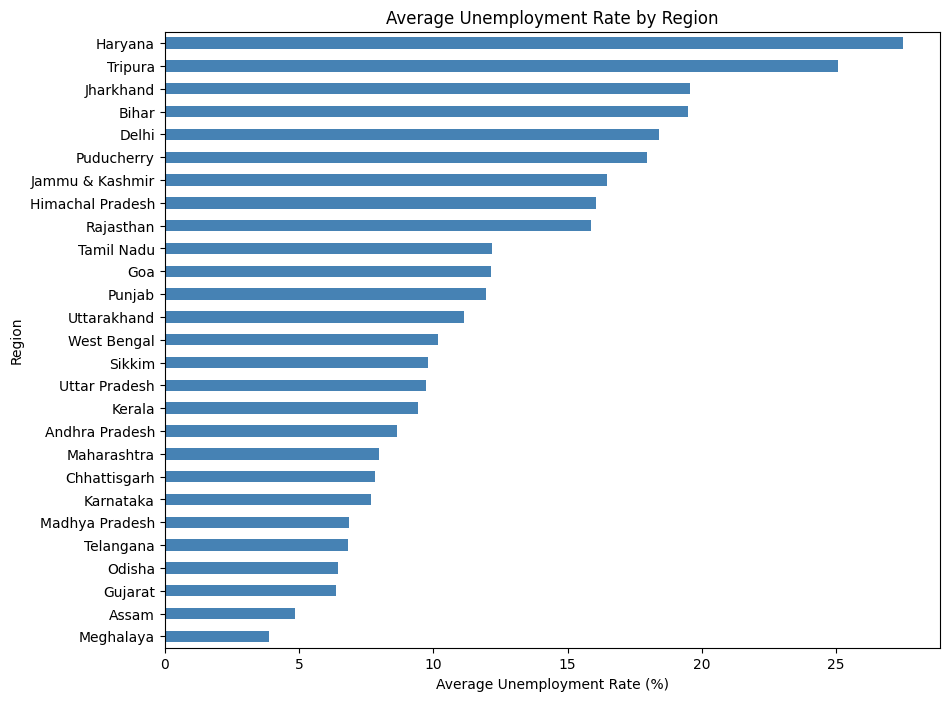

Region
Haryana             27.477000
Tripura             25.055000
Jharkhand           19.539000
Bihar               19.471000
Delhi               18.414000
Puducherry          17.942000
Jammu & Kashmir     16.477778
Himachal Pradesh    16.065000
Rajasthan           15.868000
Tamil Nadu          12.187000
Goa                 12.167000
Punjab              11.981000
Uttarakhand         11.156000
West Bengal         10.192000
Sikkim               9.792500
Uttar Pradesh        9.737000
Kerala               9.434000
Andhra Pradesh       8.664000
Maharashtra          7.979000
Chhattisgarh         7.819000
Karnataka            7.668000
Madhya Pradesh       6.854000
Telangana            6.833000
Odisha               6.462000
Gujarat              6.376000
Assam                4.856000
Meghalaya            3.866000
Name: Estimated Unemployment Rate (%), dtype: float64


In [18]:
region_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
region_avg.plot(kind='barh', color='steelblue')
plt.xlabel('Average Unemployment Rate (%)')
plt.title('Average Unemployment Rate by Region')
plt.gca().invert_yaxis()
plt.show()

print(region_avg)

**Observations:**
- Haryana has the highest average unemployment rate (27.47%), followed by Tripura, Jharkhand, Bihar, and Delhi.
- Meghalaya, Sikkim, and Uttar Pradesh have the lowest average unemployment rates.
- There is a wide gap between the highest and lowest states, suggesting unemployment impact varied significantly by region.

## 6. Month-wise Unemployment Trend (All India Average)

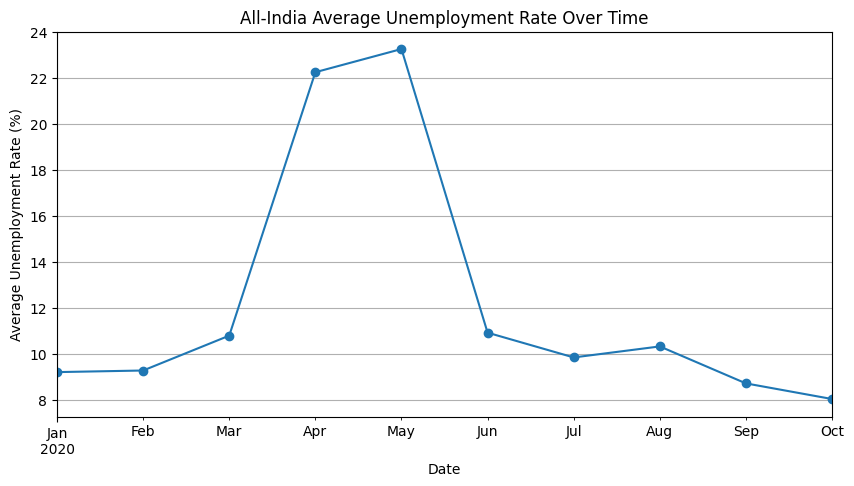

In [17]:
monthly_avg = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(10, 5))
monthly_avg.plot(marker='o')
plt.xlabel('Date')
plt.ylabel('Average Unemployment Rate (%)')
plt.title('All-India Average Unemployment Rate Over Time')
plt.grid(True)
plt.show()

**Observations:**
- The unemployment rate was low and stable in January–February 2020 (around 7-8%).
- It spiked sharply in April 2020, reaching close to 24% — this aligns directly with India's nationwide COVID-19 lockdown, which began on 25 March 2020.
- The rate declined gradually from May through October 2020 as lockdown restrictions eased, though it had not fully returned to pre-lockdown levels by October.
- This confirms that the COVID-19 lockdown caused a sharp, temporary shock to employment across India.

## 7. Unemployment Trend for Selected States

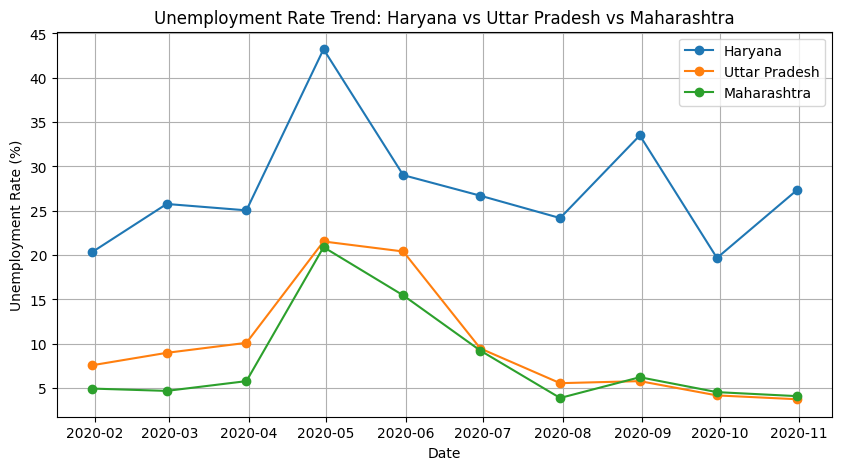

In [16]:
states = ['Haryana', 'Uttar Pradesh', 'Maharashtra']

plt.figure(figsize=(10, 5))
for state in states:
    state_data = df[df['Region'] == state]
    plt.plot(state_data['Date'], state_data['Estimated Unemployment Rate (%)'], marker='o', label=state)

plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.title('Unemployment Rate Trend: Haryana vs Uttar Pradesh vs Maharashtra')
plt.legend()
plt.grid(True)
plt.show()

**Observations:**
- Uttar Pradesh shows the sharpest and highest spike (close to 45% in April 2020), even though its overall average was lower — this means its unemployment rate was usually low but reacted very strongly during the lockdown month.
- Haryana's rate is consistently high across most months (rarely dropping below 15-20%), which explains its high overall average, even though its peak spike is lower than Uttar Pradesh's.
- Maharashtra shows a moderate, relatively stable pattern throughout, with a smaller spike than either Haryana or Uttar Pradesh.
- This shows that "high average" and "high volatility/spike" are different things — Haryana had a persistently high rate, while Uttar Pradesh had a short but extreme shock.

## 8. Top 10 States by Average Unemployment Rate

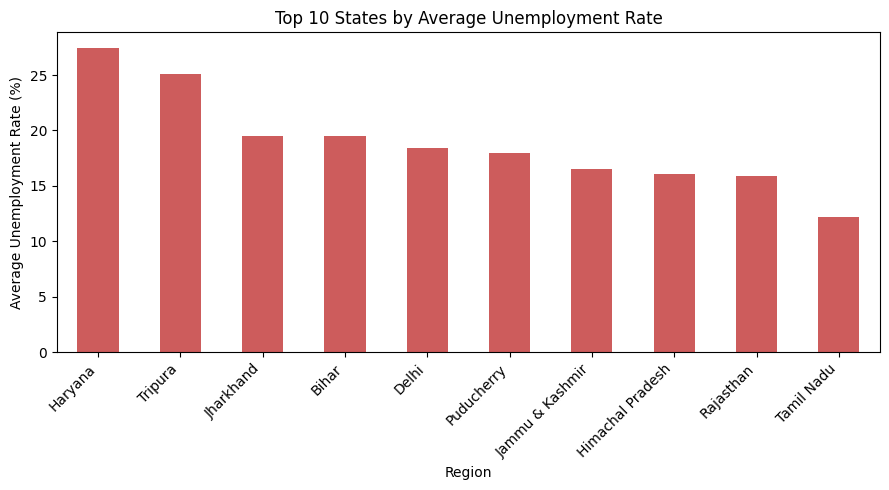

In [15]:
top10 = region_avg.head(10)

plt.figure(figsize=(9, 5))
top10.plot(kind='bar', color='indianred')
plt.ylabel('Average Unemployment Rate (%)')
plt.title('Top 10 States by Average Unemployment Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 9. Correlation Heatmap

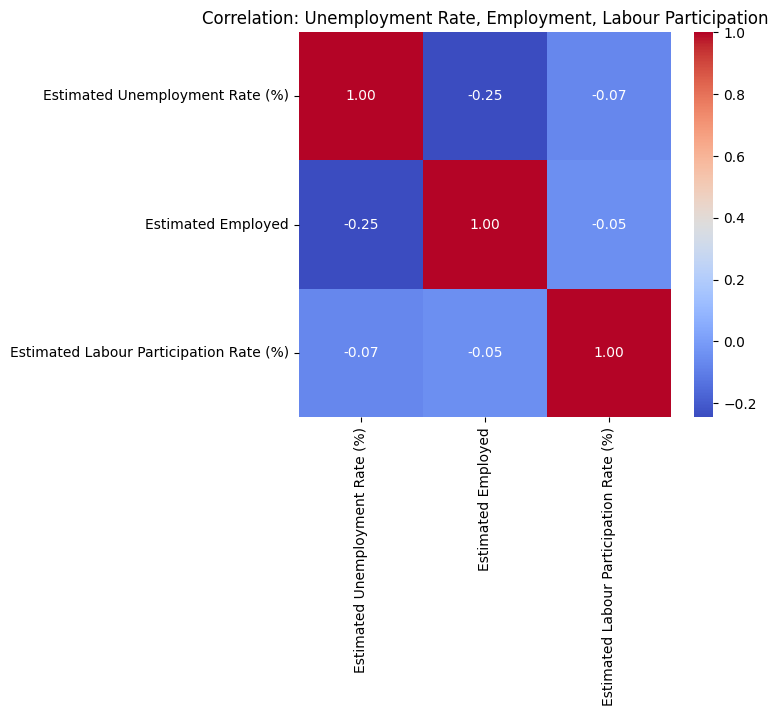

In [14]:
numeric_cols = ['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']

plt.figure(figsize=(6, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation: Unemployment Rate, Employment, Labour Participation')
plt.show()

**Observations:**
- Estimated Employed and Estimated Labour Participation Rate are strongly positively correlated (0.85) — when more people participate in the labour force, more people are employed, as expected.
- Estimated Unemployment Rate has a weak correlation with both Estimated Employed (0.25) and Labour Participation Rate (-0.07), suggesting unemployment rate changes are driven more by economic shocks (like the lockdown) than by simple shifts in labour force size.

## 10. Pre-COVID vs Post-COVID Comparison

In [13]:
# We already established: Jan-Feb 2020 = pre-lockdown, Mar 2020 onward = post-lockdown
pre_covid = df[df['Date'] < '2020-03-01']
post_covid = df[df['Date'] >= '2020-03-01']

comparison = pd.DataFrame({
    'Pre-COVID (Jan-Feb 2020)': [
        pre_covid['Estimated Unemployment Rate (%)'].mean(),
        pre_covid['Estimated Labour Participation Rate (%)'].mean(),
    ],
    'Post-COVID (Mar-Oct 2020)': [
        post_covid['Estimated Unemployment Rate (%)'].mean(),
        post_covid['Estimated Labour Participation Rate (%)'].mean(),
    ]
}, index=['Avg Unemployment Rate (%)', 'Avg Labour Participation Rate (%)'])

comparison['Change'] = comparison['Post-COVID (Mar-Oct 2020)'] - comparison['Pre-COVID (Jan-Feb 2020)']
comparison

,Pre-COVID (Jan-Feb 2020),Post-COVID (Mar-Oct 2020),Change
Avg Unemployment Rate (%),9.231346,12.963860,3.732514
Avg Labour Participation Rate (%),44.403654,41.023209,-3.380445


**Observations:**
- The average unemployment rate rose from 9.23% (pre-COVID) to 12.98% (post-COVID), an increase of about 3.75 percentage points.
- The average labour participation rate fell from 44.44% to 41.02%, a drop of about 3.38 percentage points.
- Both changes point the same way: fewer people were participating in the labour force, and among those who were, more were unemployed.
- The pre/post averages understate the severity of the shock, since they smooth over the sharp April 2020 spike (close to 24%) shown in the earlier time-series chart, followed by gradual recovery through October.

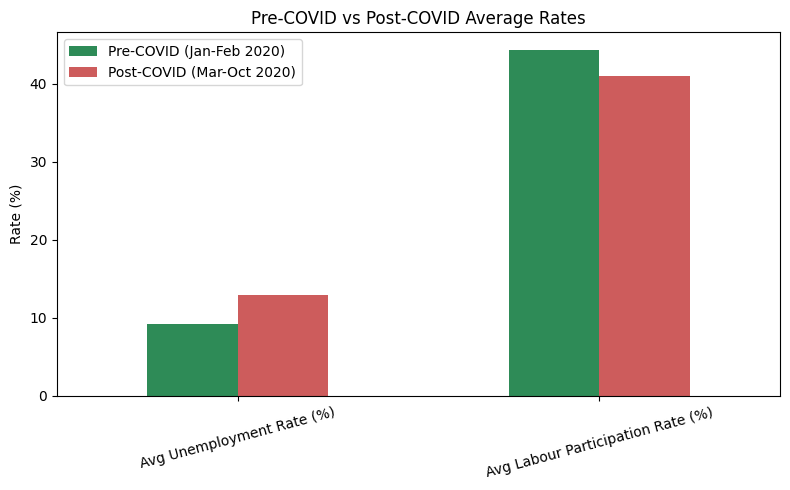

In [12]:
comparison[['Pre-COVID (Jan-Feb 2020)', 'Post-COVID (Mar-Oct 2020)']].plot(
    kind='bar', figsize=(8, 5), color=['seagreen', 'indianred']
)
plt.ylabel('Rate (%)')
plt.title('Pre-COVID vs Post-COVID Average Rates')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Conclusion

**Key Findings:**
- India's average unemployment rate rose sharply during the COVID-19 lockdown, spiking to nearly 24% in April 2020 before gradually recovering through October 2020.
- Haryana had the highest average unemployment rate (27.47%) throughout the period, while Uttar Pradesh experienced the sharpest single-month spike (close to 45% in April 2020) despite a lower overall average.
- Labour participation rate declined post-lockdown, indicating that many people also exited the workforce entirely, not just lost jobs.
- Employment count and labour participation rate are strongly correlated (0.85), while unemployment rate is more independent, driven by external shocks like the lockdown rather than gradual workforce changes.

**Business/Policy Recommendations:**
1. States with persistently high unemployment (Haryana, Tripura, Jharkhand, Bihar) may need targeted long-term employment programs, not just pandemic relief.
2. States with sharp but short-lived spikes (Uttar Pradesh) may benefit more from emergency income-support programs during future shocks, since their underlying employment base recovers relatively well.
3. The decline in labour participation rate suggests policies should also address workforce re-entry, not just job creation, since some people appear to have left the labour force entirely during the lockdown.

**Limitation:** This dataset only covers January–October 2020, so we cannot compare against a pre-2020 baseline or see whether unemployment fully returned to pre-pandemic levels after October.